# Linear Regression for Interpretable Churn Prediction - Alberto

**Assignment:** Assumption Junction, Individual Notebook (Model 1: Linear Regression)

**Goal:** Fit a linear probability model (OLS) to predict customer churn, check whether the linear regression assumptions hold, and judge whether this model is a responsible choice for explaining churn to the business.

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) (IBM sample dataset), one row per customer with account, billing, and service features, plus a `Churn` label (`Yes`/`No`).


## 1. Imports

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, recall_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera

sns.set_style("whitegrid")
RANDOM_STATE = 42

### Dataset file

This notebook uses `WA_Fn-UseC_-Telco-Customer-Churn.csv`. Make sure the CSV file is uploaded in the same folder as the notebook before running the code.

## 2. Dataset Loading and Cleaning

First we load the Telco Customer Churn dataset and check its shape to see how many rows and columns we have. Then we display the first few rows to get a quick look at the data.

In [86]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Now we check the data types of each column and see if there are any missing values before cleaning the dataset.

In [87]:
# Data types and missing values before cleaning
print(df.dtypes)
print("\nMissing values (NaN) per column:", df.isnull().sum().sum())

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values (NaN) per column: 0


Here we check why `TotalCharges` is stored as an object and find the rows that contain a blank value instead of a number.

In [88]:
# TotalCharges is object dtype because 11 rows hold a blank string instead of a number
blank_mask = df["TotalCharges"].str.strip() == ""
print(f"Rows with blank TotalCharges: {blank_mask.sum()}")
df.loc[blank_mask, ["tenure", "MonthlyCharges", "TotalCharges"]]

Rows with blank TotalCharges: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


Now we convert `TotalCharges` to numeric. The 11 blank values all belong to customers with `tenure = 0`, so we treat them as new customers and replace their blank total charge with 0. We also remove `customerID` and encode `Churn` as 0/1.

In [89]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Drop the identifier, encode the target
df = df.drop(columns=["customerID"])
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(f"Clean shape: {df.shape}")
print(f"Churn rate: {df['Churn'].mean():.1%}")
df.dtypes

Clean shape: (7043, 20)
Churn rate: 26.5%


,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


### Collapsing redundant service categories

Now we simplify some redundant categories before encoding. "No internet service" and "No phone service" indicate that the customer cannot have the corresponding add-on because they do not have the base service. Since the base service status is already represented by InternetService and PhoneService, we collapse these categories into "No" to reduce redundant information before encoding.

In [90]:
internet_dependent_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]

for col in internet_dependent_cols:
    df[col] = df[col].replace("No internet service", "No")

df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")

print(df["OnlineSecurity"].unique())
print(df["MultipleLines"].unique())

['No' 'Yes']
['No' 'Yes']


### One-hot encoding (for categorical variables)

Now we convert the remaining categorical variables into numeric dummy columns so they can be used by the models. We use `drop_first=True` to avoid redundant columns and perfect multicollinearity.

We use one-hot encoding instead of ordinal encoding because these categories do not have a natural order. Assigning values like 0, 1, and 2 could make the model interpret an order or distance between categories that does not actually exist. One-hot encoding represents each category separately without introducing this false relationship.

In [91]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# get_dummies returns bool columns, convert to int for cleaner stats/plots later
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"Encoded shape: {df_encoded.shape}")
df_encoded.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Encoded shape: (7043, 24)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,1,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,0,...,1,1,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


### Final cleaning check

Before moving to the assumption checks, we verify that there are no missing values left and confirm the final size of the encoded dataset.

In [92]:
print("Missing values after cleaning:", df_encoded.isnull().sum().sum())
print("Final shape:", df_encoded.shape)

Missing values after cleaning: 0
Final shape: (7043, 24)


### Data type check

Finally, we check the column types to make sure all features are numeric and ready to use in the model.

In [93]:
df_encoded.dtypes.value_counts()

,count
int64,22
float64,2


### Duplicate check

Before moving to the assumption checks, we check whether any rows have identical values across all remaining features. Since `customerID` has already been removed, identical rows do not necessarily represent duplicated customers; different customers may simply share the same characteristics.

In [94]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 22


There are 22 identical rows after removing `customerID`. We keep them because we cannot determine that they correspond to duplicate customers.

## 3. Exploratory Data Analysis: Checking Linear Regression Assumptions

Here we are going to check six important assumptions and diagnostics for linear regression. Some can be investigated before fitting the model, while others require the fitted values and residuals and will therefore be checked after training the model.

1. **Linearity**: predictors relate to the target roughly linearly.
2. **No multicollinearity**: predictors aren't near-duplicates of each other.
3. **Homoscedasticity**: residual variance is constant.
4. **Normality of residuals**: mostly matters for inference rather than point predictions.
5. **Independence**: observations don't depend on each other.
6. **No influential outliers**: no single observation strongly dominates the fitted model.


**Independence of observations:** This assumption seems reasonable because each row represents a different customer and there are no repeated measurements or an explicit time sequence. However, independence cannot be fully verified from the available data because there could still be unobserved clustering between customers.

### 3.1 Target class balance

First we will check if the binary target class is balanced or not.

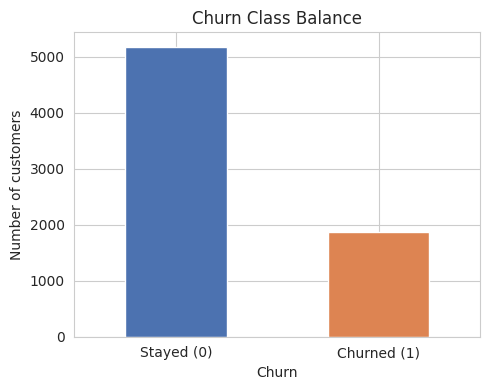

In [95]:
plt.figure(figsize=(5, 4))
df["Churn"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.xticks([0, 1], ["Stayed (0)", "Churned (1)"], rotation=0)
plt.ylabel("Number of customers")
plt.title("Churn Class Balance")
plt.tight_layout()
plt.show()

The target is binary, which is the first indication that linear regression (a model designed for continuous outcomes) is not a natural fit. In addition, only ~27% of observations are churn cases, indicating some class imbalance.

### 3.2 Linearity: numeric predictors vs. churn

Here we first compare the numeric features between customers who stayed and customers who churned. These boxplots help us understand how the distributions differ between the two groups.

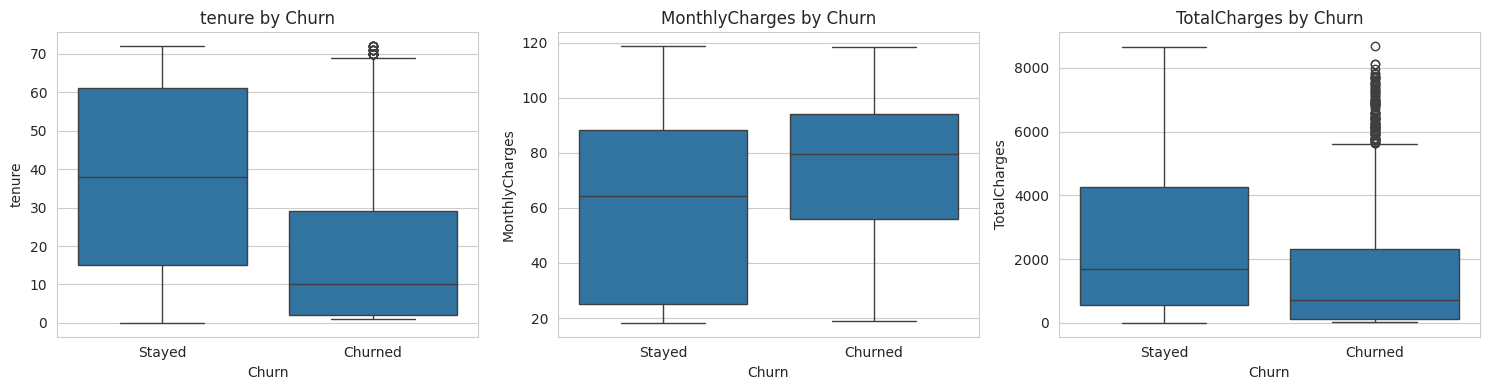

In [96]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_cols):

    sns.boxplot(data=df, x="Churn", y=col, ax=ax)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Stayed", "Churned"])

    ax.set_title(f"{col} by Churn")

plt.tight_layout()
plt.show()

These boxplots show that customers who churn tend to have lower `tenure`. However, differences between the two groups do not directly test the linearity assumption.

We initially inspect all three numeric variables here. In the next section, the multicollinearity analysis shows that `MonthlyCharges` and `TotalCharges` contain substantial redundant information and are removed from the final feature set. Therefore, `tenure` is the only continuous predictor retained in the final model, so we check its linearity more directly below.

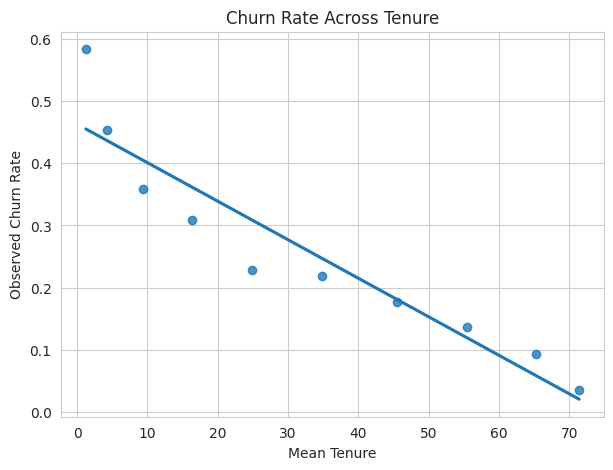

In [97]:
# Check whether churn probability changes approximately linearly with tenure
tenure_bins = pd.qcut(df["tenure"], q=10, duplicates="drop")

tenure_linearity = (
    df.groupby(tenure_bins, observed=True)
      .agg(
          mean_tenure=("tenure", "mean"),
          churn_rate=("Churn", "mean")
      )
      .reset_index(drop=True)
)

plt.figure(figsize=(7, 5))

sns.regplot(
    data=tenure_linearity,
    x="mean_tenure",
    y="churn_rate",
    ci=None
)

plt.xlabel("Mean Tenure")
plt.ylabel("Observed Churn Rate")
plt.title("Churn Rate Across Tenure")
plt.show()

The observed churn rate decreases as `tenure` increases, following a reasonably linear downward trend. There are some small deviations, especially for customers with very low tenure, but there is no strong curved pattern.

This suggests that the linearity assumption for `tenure` is reasonably supported.

### 3.3 Multicollinearity: correlation, VIF, and a fix along the way

Here we check for multicollinearity between the predictors. Multicollinearity happens when some features contain very similar information, which can make the individual coefficients of a linear regression harder to interpret.

We first use a correlation heatmap to look for strong relationships between the numeric variables. Then, we use the Variance Inflation Factor (VIF) to check multicollinearity across the full feature set, including the categorical dummy variables.

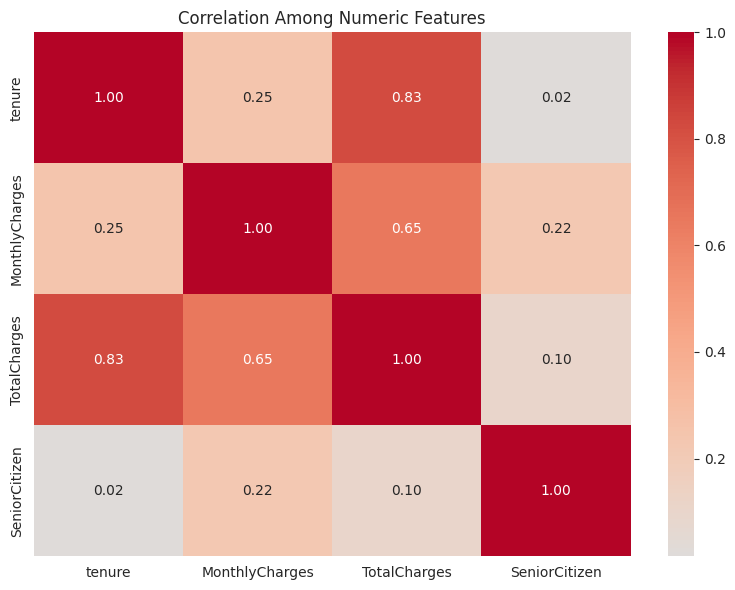

In [98]:
plt.figure(figsize=(8, 6))
corr = df[numeric_cols + ["SeniorCitizen"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Among Numeric Features")
plt.tight_layout()
plt.show()

`tenure` and `TotalCharges` correlate at about 0.83, which makes sense because customers who have been with the company for longer generally accumulate higher total charges.

To check the full feature set, including the categorical dummy variables, we compute the Variance Inflation Factor (VIF) for every predictor. High VIF values indicate that a feature contains substantial information that is also explained by other predictors.

In [99]:
X_check = df_encoded.drop(columns=["Churn"]).astype(float)
X_check_const = sm.add_constant(X_check)

vif_data = pd.DataFrame({
    "feature": X_check_const.columns,
    "VIF": [variance_inflation_factor(X_check_const.values, i) for i in range(X_check_const.shape[1])]
})
vif_data = vif_data[vif_data["feature"] != "const"].sort_values("VIF", ascending=False)
vif_data.head(10)

,feature,VIF
3,MonthlyCharges,865.062147
10,InternetService_Fiber optic,148.263380
11,InternetService_No,104.217482
8,PhoneService_Yes,34.861565
17,StreamingMovies_Yes,24.110253
16,StreamingTV_Yes,24.056827
4,TotalCharges,10.793729
2,tenure,7.527280
9,MultipleLines_Yes,7.273906
14,DeviceProtection_Yes,6.922434


Several features have very high VIF values, especially `MonthlyCharges`, which suggests strong multicollinearity in the current feature set.

Before deciding what to remove, we also check whether any feature has an infinite VIF. An infinite VIF would indicate perfect redundancy between predictors.

In [100]:
inf_features = vif_data[~np.isfinite(vif_data["VIF"])]
print(f"Features with infinite VIF: {len(inf_features)}")
inf_features

Features with infinite VIF: 0


,feature,VIF


There are no features with infinite VIF. This confirms that the redundant service categories we collapsed earlier are no longer creating perfectly duplicated predictors. For example, without this cleaning, `InternetService_No` and a `"No internet service"` dummy from the service columns would contain the same information.

Several predictors still have high VIF values. `MonthlyCharges` stands out because it is strongly related to the combination of services a customer pays for. `TotalCharges` also overlaps with `tenure` and `MonthlyCharges`, since it accumulates charges over time.

To reduce this redundancy, we remove `MonthlyCharges` and `TotalCharges` and keep `tenure` plus the individual service features. This gives us a simpler and easier-to-interpret feature set.

In [101]:
df_encoded = df_encoded.drop(columns=["MonthlyCharges", "TotalCharges"])
print(f"Shape after dropping the charge columns: {df_encoded.shape}")

Shape after dropping the charge columns: (7043, 22)


In [102]:
X_final_check = df_encoded.drop(columns=["Churn"]).astype(float)
X_final_check_const = sm.add_constant(X_final_check)

vif_final = pd.DataFrame({
    "feature": X_final_check_const.columns,
    "VIF": [variance_inflation_factor(X_final_check_const.values, i) for i in range(X_final_check_const.shape[1])]
})
vif_final = vif_final[vif_final["feature"] != "const"].sort_values("VIF", ascending=False)
vif_final.head(10)

,feature,VIF
2,tenure,2.785135
9,InternetService_No,2.698749
17,Contract_Two year,2.613895
8,InternetService_Fiber optic,2.006234
20,PaymentMethod_Electronic check,1.973799
21,PaymentMethod_Mailed check,1.841066
15,StreamingMovies_Yes,1.633899
14,StreamingTV_Yes,1.626085
16,Contract_One year,1.621942
19,PaymentMethod_Credit card (automatic),1.560358


Every VIF is now under 3, so there is no strong evidence of problematic multicollinearity in the final feature set.

## 4. Linear Regression Model (Linear Probability Model)

Here we fit a linear regression model using `Churn` (0/1) as the target. Because the target is binary, this is a Linear Probability Model (LPM). The predictions can be interpreted as estimated churn probabilities, although linear regression does not force them to stay between 0 and 1.

In [103]:
# Separate the features from the target variable
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# Split the data into training and test sets, keeping the same churn proportion in both
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale the features using the training data
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Apply the same scaling to the test data
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")

Train shape: (5634, 21), Test shape: (1409, 21)


In [104]:
# Create and train the linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions on the training and test sets
y_pred_train = lr_model.predict(X_train_scaled)
y_pred_test = lr_model.predict(X_test_scaled)

print("Model fitted.")

Model fitted.


## 5. Model Performance Evidence

Now that the model is fitted, we evaluate how well it performs on the test set. We first look at standard regression metrics such as MSE, RMSE, and R². Since `Churn` is binary, we also use a 0.5 threshold to convert the predictions into classes and inspect the accuracy and confusion matrix.

In [105]:
# Evaluate the model on the test set
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("Linear Regression (Linear Probability Model), test set")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

Linear Regression (Linear Probability Model), test set
MSE:  0.1437
RMSE: 0.3791
R2:   0.2630


The regression metrics give us an idea of how well the model fits the data. Since `Churn` is binary, we also convert the predictions into 0/1 classes using a 0.5 threshold to see how often the model correctly identifies customers who stayed or churned.

Accuracy @ 0.5 threshold: 0.798
Churn recall: 0.505


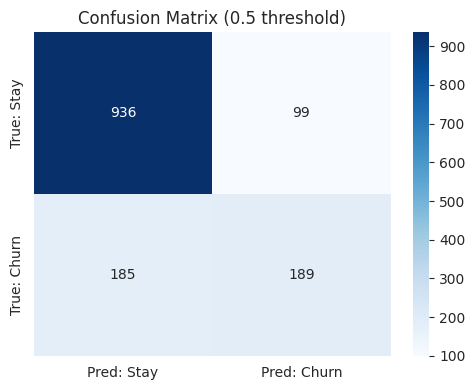

In [106]:
# Convert predictions into binary classes using a 0.5 threshold
y_pred_class = (y_pred_test >= 0.5).astype(int)

# Calculate classification accuracy
acc = accuracy_score(y_test, y_pred_class)

# Calculate recall for customers who actually churned
churn_recall = recall_score(y_test, y_pred_class)

print(f"Accuracy @ 0.5 threshold: {acc:.3f}")
print(f"Churn recall: {churn_recall:.3f}")

# Create and display the confusion matrix
cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred: Stay", "Pred: Churn"],
    yticklabels=["True: Stay", "True: Churn"]
)

plt.title("Confusion Matrix (0.5 threshold)")
plt.tight_layout()
plt.show()

Using a 0.5 threshold, the model correctly classifies about 79.8% of the test customers.

The churn recall is about 50.5%, meaning that the model correctly identifies only around half of the customers who actually churn.

In [107]:
# Check if any predictions fall outside the valid probability range [0, 1]
below_zero = (y_pred_test < 0).sum()
above_one = (y_pred_test > 1).sum()
total = len(y_pred_test)

print(f"Predictions below 0: {below_zero} ({below_zero/total:.1%})")
print(f"Predictions above 1: {above_one} ({above_one/total:.1%})")
print(f"Predicted value range: [{y_pred_test.min():.3f}, {y_pred_test.max():.3f}]")

Predictions below 0: 237 (16.8%)
Predictions above 1: 0 (0.0%)
Predicted value range: [-0.243, 0.787]


About 16.8% of the test predictions fall below 0, with a minimum of about -0.24. This is an important limitation of the Linear Probability Model, since predicted probabilities should normally stay between 0 and 1.

### Residual diagnostics

Now that the model is fitted, we use the residuals to check two remaining assumptions: constant variance (homoscedasticity) and normality of the residuals.

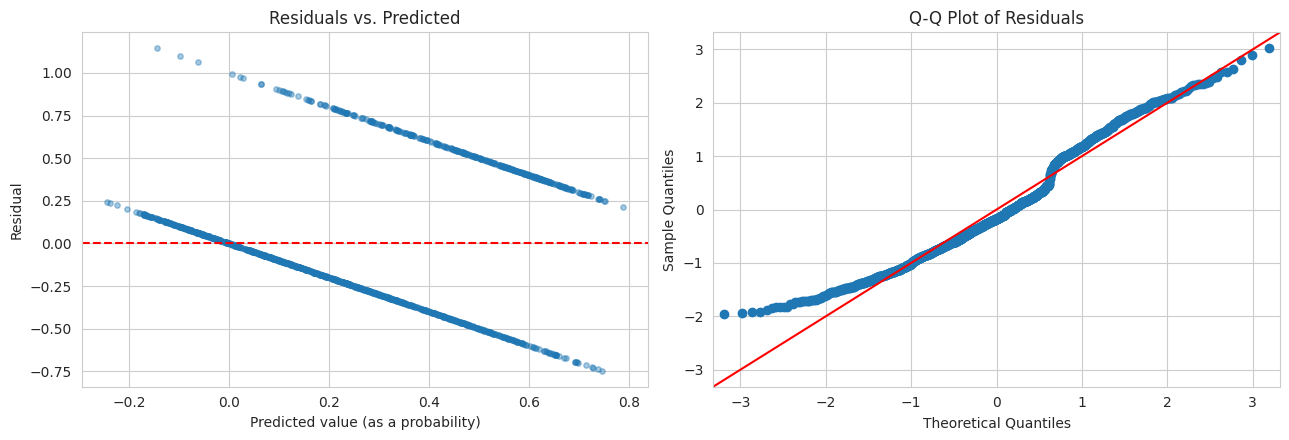

In [108]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_pred_test, residuals, alpha=0.4, s=15)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted value (as a probability)")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs. Predicted")

sm.qqplot(residuals, line="45", fit=True, ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

The residual plot forms two diagonal bands because `Churn` is binary. For a Linear Probability Model, heteroscedasticity is expected with a binary target, so we test it formally below.

The Q-Q plot deviates from the reference line, suggesting that the residuals are not normally distributed. We check both assumptions formally below.

In [109]:
X_train_const = sm.add_constant(X_train_scaled)
ols_model = sm.OLS(y_train, X_train_const).fit()

bp_stat, bp_pvalue, _, _ = het_breuschpagan(ols_model.resid, X_train_const)
print(f"Breusch-Pagan p-value: {bp_pvalue:.2e}")
print("Reject H0 (constant variance): heteroscedasticity is present" if bp_pvalue < 0.05
      else "Fail to reject H0: no strong evidence of heteroscedasticity")

Breusch-Pagan p-value: 6.83e-226
Reject H0 (constant variance): heteroscedasticity is present


In [110]:
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(ols_model.resid)
print(f"Jarque-Bera p-value: {jb_pvalue:.2e}")
print("Reject H0 (normal residuals): residuals are not normally distributed" if jb_pvalue < 0.05
      else "Fail to reject H0: no strong evidence against normality")

Jarque-Bera p-value: 2.68e-68
Reject H0 (normal residuals): residuals are not normally distributed


Both tests have p-values close to zero, providing strong evidence of heteroscedasticity and non-normal residuals.

Heteroscedasticity makes conventional OLS inference less reliable, while non-normal residuals are not surprising because the target is binary. Overall, these results show that some of the usual OLS error assumptions are violated for this problem.

### Influential observations: Cook's distance

Finally, we check whether a small number of customers have a large influence on the fitted model. Cook's Distance measures how much the regression fit could change if one observation were removed. We use `4/n` as a screening threshold for observations that may deserve further inspection.

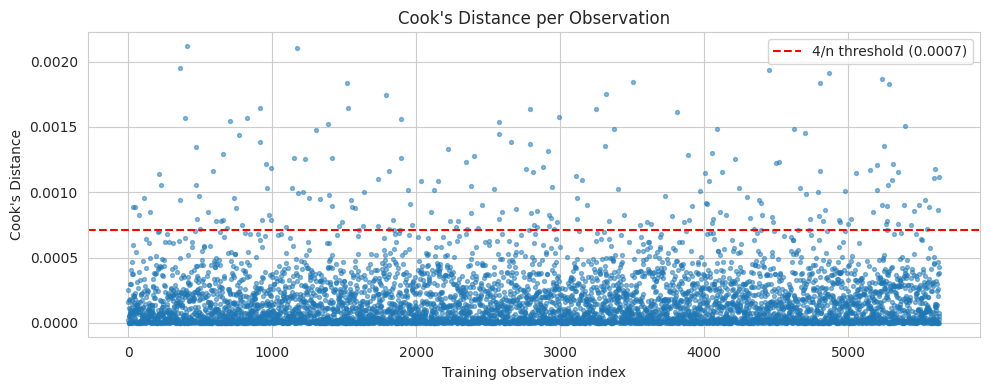

Observations above the 4/n threshold: 209 (3.7%)
Maximum Cook's Distance: 0.0021


In [111]:
influence = ols_model.get_influence()
cooks_d = influence.cooks_distance[0]
threshold = 4 / len(cooks_d)

plt.figure(figsize=(10, 4))
plt.scatter(range(len(cooks_d)), cooks_d, s=8, alpha=0.5)
plt.axhline(threshold, color="red", linestyle="--", label=f"4/n threshold ({threshold:.4f})")
plt.xlabel("Training observation index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance per Observation")
plt.legend()
plt.tight_layout()
plt.show()

n_flagged = (cooks_d > threshold).sum()
print(f"Observations above the 4/n threshold: {n_flagged} ({n_flagged/len(cooks_d):.1%})")
print(f"Maximum Cook's Distance: {cooks_d.max():.4f}")

209 observations (3.7% of the training data) exceed the `4/n` screening threshold, so these observations could be inspected further.

The maximum Cook's Distance is 0.0021, but the plot does not show any single observation that clearly stands out from the rest or dominates the fit.

Overall, there is no strong evidence that the model is being driven by one highly influential customer.

## 6. Coefficient Interpretation

Now we look at the model coefficients to understand which features are associated with higher or lower predicted churn probability.

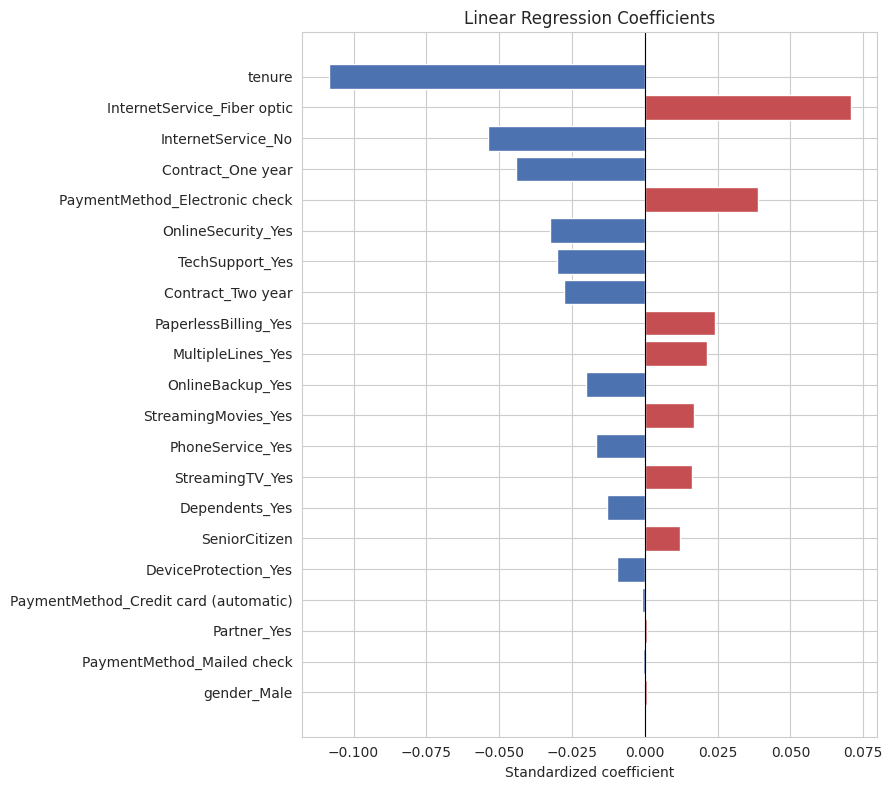

,feature,standardized_coefficient,original_scale_coefficient
1,tenure,-0.108560,-0.004419
7,InternetService_Fiber optic,0.070670,0.142345
8,InternetService_No,-0.053806,-0.130867
15,Contract_One year,-0.044175,-0.108801
19,PaymentMethod_Electronic check,0.038873,0.082320
9,OnlineSecurity_Yes,-0.032426,-0.071602
12,TechSupport_Yes,-0.030188,-0.066348
16,Contract_Two year,-0.027657,-0.064647
17,PaperlessBilling_Yes,0.024060,0.048941
6,MultipleLines_Yes,0.021507,0.043517


In [112]:
# Store both standardized coefficients and coefficients in the original feature scale
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "standardized_coefficient": lr_model.coef_,
    "original_scale_coefficient": lr_model.coef_ / scaler.scale_
})

# Sort by standardized coefficient magnitude so coefficients are easier to compare
coef_df = coef_df.sort_values(
    "standardized_coefficient",
    key=abs,
    ascending=False
)

plt.figure(figsize=(9, 8))
colors = [
    "#C44E52" if c > 0 else "#4C72B0"
    for c in coef_df["standardized_coefficient"]
]

plt.barh(
    coef_df["feature"],
    coef_df["standardized_coefficient"],
    color=colors
)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Standardized coefficient")
plt.title("Linear Regression Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

coef_df.head(10)

The model was trained using standardized features, which makes the coefficient magnitudes easier to compare. For interpretation, we also convert the coefficients back to their original scale.

Because this is a Linear Probability Model, the original-scale coefficients can be interpreted as changes in predicted churn probability, holding the other features constant. These are associations, not causal effects.

Some examples:

- **`tenure` (-0.0044):** Each additional month of tenure is associated with about a **0.44 percentage point decrease** in predicted churn probability.

- **`InternetService_Fiber optic` (+0.1423):** Customers with fiber optic internet have about a **14.2 percentage point higher** predicted churn probability than customers with DSL.

- **`Contract_One year` (-0.1088):** Customers with a one-year contract have about a **10.9 percentage point lower** predicted churn probability than customers with a month-to-month contract.

- **`PaymentMethod_Electronic check` (+0.0823):** Customers who pay by electronic check have about an **8.2 percentage point higher** predicted churn probability than customers using bank transfer (automatic).

- **`TechSupport_Yes` (-0.0663):** Customers with tech support have about a **6.6 percentage point lower** predicted churn probability than customers without tech support.

## 7. Limitations of Linear Regression for Churn

Finally, we summarize the main limitations of using linear regression for a binary churn outcome.

1. **Predictions are not always valid probabilities.** About 17% of the test predictions fall below 0, with values as low as approximately -0.24. Since probabilities must be between 0 and 1, this is an important limitation of the Linear Probability Model.

2. **Heteroscedasticity.** The Breusch-Pagan test shows that the residual variance is not constant. This makes standard OLS inference, such as standard errors and p-values, less reliable.

3. **Non-normal residuals.** The Jarque-Bera test rejects normality. This is expected with a binary target and shows that the usual linear regression error assumptions are not a perfect fit for this problem.

4. **The relationship is forced to remain linear.** The LPM assumes that each feature changes churn probability at a constant rate, which can lead to unrealistic predictions near 0 and 1.

The main advantage of the LPM is that its coefficients are easy to interpret. However, because of these limitations, it is more useful as a simple interpretable baseline than as a production model for churn probabilities. A model designed for binary outcomes, such as logistic regression, would be more appropriate for that purpose.